**E-HEALTH - LABORATORY 3**

**DOWNLOAD THE DATASET**

In this laboratory, we will use the data that are available at link https://drive.google.com/file/d/1Bo5rCQYoeoCzKrMi8rMpVsjqfyuqDMVH/view?usp=sharing

We download the folder and add the data to the COLAB Notebook.

In [1]:
%pip install googledrivedownloader
from googledrivedownloader import download_file_from_google_drive
import zipfile

download_file_from_google_drive(file_id='1Bo5rCQYoeoCzKrMi8rMpVsjqfyuqDMVH',
                                dest_path='./ehealth_lab_3.zip',
                                unzip=False,
                                overwrite=True)

with zipfile.ZipFile("./ehealth_lab_3.zip","r") as zip_ref:
    zip_ref.extractall("./ehealth_lab_3")

path_to_dataset_folder = "./ehealth_lab_3/"

We install and import `mne` and other useful Python packages.

In [2]:
%pip install mne
import mne
import os
import scipy
import numpy as np
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 54.5 MB/s eta 0:00:00


We define a method for plotting the results as a time series.

In [3]:
def plot_series(times: np.ndarray,
                series: np.ndarray,
                xlabel: str,
                ylabel: str,
                xlim: list = None,
                ylim: list = None,
                title: str = None,
                plot_num: int = None):

  # The variable plot_num determines the number of time points that we want to analyze
  # If plot_num is lower than the data number we represent both the median and the interquartile range of the data in time

  fig = plt.figure()

  if plot_num is not None:

    plot_num = np.min((plot_num, len(series)))

    sample_num = int(len(series) / plot_num)

    data = np.reshape(series[:sample_num * plot_num], (sample_num, plot_num))
    times = np.reshape(times[:sample_num * plot_num], (sample_num, plot_num))

    data_medians = np.median(data, axis=1)

    times = np.median(times, axis=1)
    data_75percent = np.percentile(data, 75, axis=1)
    data_25percent = np.percentile(data, 25, axis=1)

  else:

    data_medians = series

  if plot_num is not None:

    plt.plot(times, data_75percent, linestyle='-', color='orangered', label='25-75 percentile')
    plt.plot(times, data_25percent, linestyle='-', color='orangered')
    plt.fill_between(times, y1=data_25percent, y2=data_75percent, color='lightsalmon')
    plt.plot(times, data_medians, linestyle='-', marker='d', color='orangered', label='Median')

    plt.legend()

  else:

    plt.plot(times, data_medians, linestyle='-', color='orangered')

  plt.grid('on')
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)

  if xlim is not None:
    plt.xlim(xlim)
  else:
    plt.xlim((times[0], times[-1]))

  if ylim is not None:
    plt.xlim(ylim)

  if title is not None:
    plt.title(title)

  fig.tight_layout()

We define a method to plot the results as multiple distibutions.

In [4]:
def plot_boxplots(data_distributions: list,
                  data_labels: np.ndarray,
                  ylabel: str,
                  xlabel: str,
                  title: str = None):

  fig = plt.figure()
  plt.boxplot(data_distributions, tick_labels=data_labels)
  plt.ylabel(ylabel)
  plt.xlabel(xlabel)
  plt.grid()

  if title is not None:
    plt.title(title)

  fig.tight_layout()

Today, we will work with a dataset of EEG signals from PhysioNet, a free-available repository of medical data, managed by MIT.

The full dataset can be found at https://physionet.org/content/eegmmidb/1.0.0/.

We consider a subset of the original data, organized in subfolders.

In [5]:
os.listdir(path_to_dataset_folder)

['S007',
 'S005',
 'S009',
 'S004',
 'S010',
 'S008',
 'S006',
 'S001',
 'S003',
 'S002']

Each subfolder is associated with a patient. We focus on patient S001.

In [6]:
patient_name = 'S001'

path_to_patient_folder = path_to_dataset_folder + patient_name + '/' # The folder of the patient that we want to study

os.listdir(path_to_patient_folder)

['S001R02.edf',
 'S001R03.edf',
 'S001R05.edf',
 'S001R01.edf',
 'S001R03.edf.event',
 'S001R06.edf.event',
 'S001R06.edf',
 'S001R02.edf.event',
 'S001R01.edf.event',
 'S001R04.edf',
 'S001R05.edf.event',
 'S001R04.edf.event']

We load one of the EEGs of the patient.

In [7]:
file_name = 'S001R01.edf' # The file that we want to study
raw_data = mne.io.read_raw_edf(path_to_patient_folder +  file_name)

Extracting EDF parameters from /content/ehealth_lab_3/S001/S001R01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


Medical information can be found in the `mne.io.Raw.annotations` attribute.

In [8]:
for annotation in raw_data.annotations:
  print(annotation)

OrderedDict([('onset', np.float64(0.0)), ('duration', np.float64(60.2)), ('description', np.str_('T0')), ('orig_time', datetime.datetime(2009, 8, 12, 16, 15, tzinfo=datetime.timezone.utc))])


Signal information are contained into the `mne.io.Raw.info` attribute.

In [9]:
raw_data.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

We save the sampling frequency, the sampling period, the number of channels, and the channel names into specific variables.

In [10]:
sampling_frequency = raw_data.info['sfreq'] # Sampling frequency
sampling_period = 1 / raw_data.info['sfreq'] # Sampling period
channel_names = raw_data.info['ch_names'] # List of channel names
channel_size = raw_data.info['nchan'] # Number of channel

We save the signal values and the time references.

In [11]:
signal_values = raw_data.get_data() * 1000  # Unit of measure in millivolt, this is a matrix
signal_times = raw_data.times  # Unit of measure in seconds
sample_size = len(signal_times) # Number of samples

We consider two channels of the signal.

In [12]:
print(channel_names)
## more than 32 channels means high density channel EEG

['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


In [13]:
channel_0_name = 'C1..' # The first channel that we want to study
channel_1_name = 'C4..' # The second channel that we want to study

In [14]:
channel_0_index = channel_names.index(channel_0_name)  # Index of the first channel that we want to study
channel_1_index = channel_names.index(channel_1_name)  # Index of the second channel that we want to study

We select the data associated with the two channels.

In [15]:
channel_0_values = signal_values[channel_0_index]  # Values of the first channel
channel_1_values = signal_values[channel_1_index]  # Values of the second channel

We represent the two channels in the time domain, considering a period of 30 seconds.

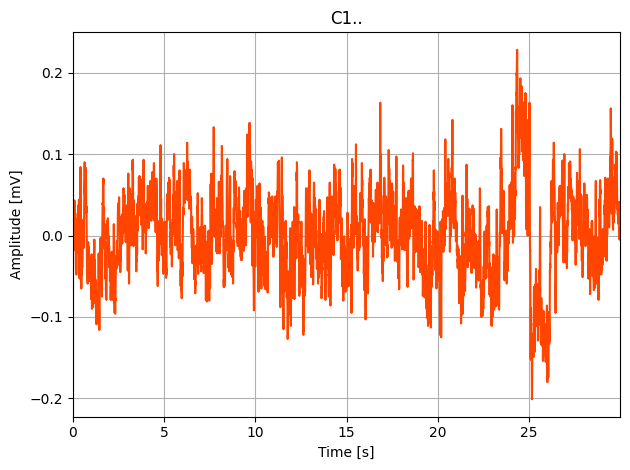

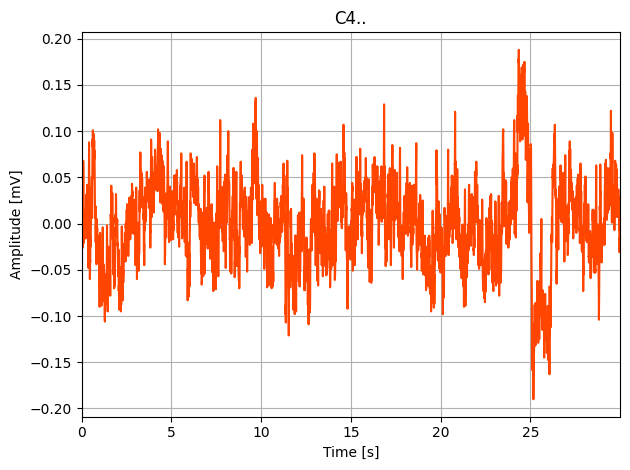

In [16]:
epoch_duration = 30 # Seconds
epoch_sample_size = int(epoch_duration / sampling_period) # Number of samples of the epoch

plot_series(signal_times[:epoch_sample_size],
            channel_0_values[:epoch_sample_size],
            'Time [s]',
            'Amplitude [mV]',
            title=channel_0_name)

plot_series(signal_times[:epoch_sample_size],
            channel_1_values[:epoch_sample_size],
            'Time [s]',
            'Amplitude [mV]',
            title=channel_1_name)

plt.show()

We exploit the Fourier Transform (FT) to compare the two channels in the frequency domain.

In [17]:
fft_frequencies = np.fft.fftfreq(sample_size, d=sampling_period)  # Frequencies associated with the Fourier Transform (FT)

channel_0_fft_values = np.fft.fft(channel_0_values) # FFT of the channel 0
channel_1_fft_values = np.fft.fft(channel_1_values) # FFT of the channel 1

We compute the Power Spectral Density (PSD) of the two channels.

In [18]:
channel_0_psd_values = np.abs(channel_0_fft_values)**2 / sample_size # PSD of the channel 0
channel_1_psd_values = np.abs(channel_1_fft_values)**2 / sample_size # PSD of the channel 1

We plot the PSD of the two channels in the frequency domain. Notably, we consider only half of the values obtained from the transformation to focus on the positive frequencies.

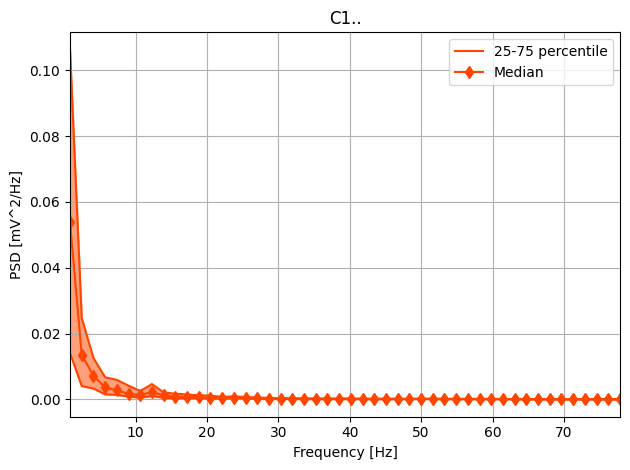

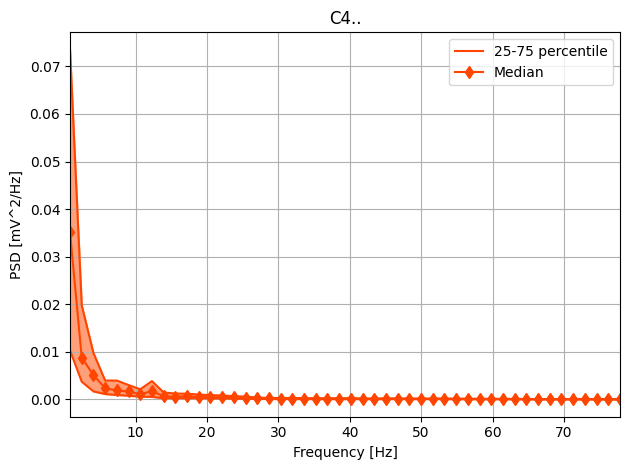

In [19]:
plot_series(fft_frequencies[:int(sample_size / 2)],
            channel_0_psd_values[:int(sample_size / 2)],
            'Frequency [Hz]',
            'PSD [mV^2/Hz]',
            title=channel_0_name,
            plot_num=100)

plot_series(fft_frequencies[:int(sample_size / 2)],
            channel_1_psd_values[:int(sample_size / 2)],
            'Frequency [Hz]',
            'PSD [mV^2/Hz]',
            title=channel_1_name,
            plot_num=100)

plt.show()

To evaluate the relation between the two channels, we consider the coherency, which is defined as the Fourier Transform (FT) of the cross-correlation, normalized by the FT of the two channels.

In [20]:
cross_correlation_values = np.convolve(channel_0_values, channel_1_values, mode='same')
fft_cross_correlation_values = np.fft.fft(cross_correlation_values)
coeherency_values = fft_cross_correlation_values / (np.abs(channel_0_fft_values) * np.abs(channel_1_fft_values))

From the coeherency, we can retrivied two distinct markers of the signal connectivty, i.e., the coherence and the imaginary coherency.

In [21]:
coherence_values = np.abs(coeherency_values)
imaginary_coherency_values = np.abs(np.imag(coeherency_values))

We plot both the coherence and the imaginary coherency in the frequency domain.

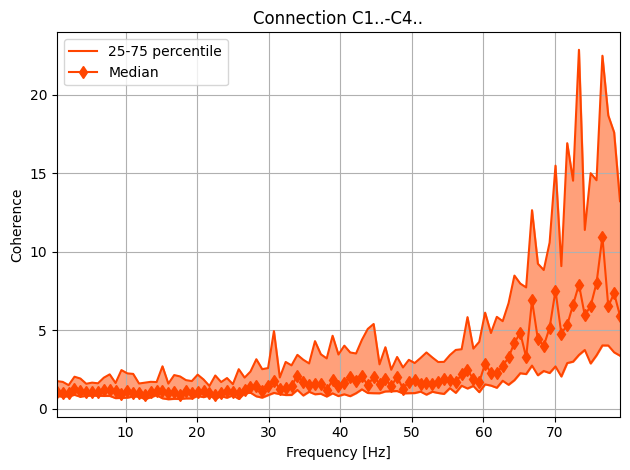

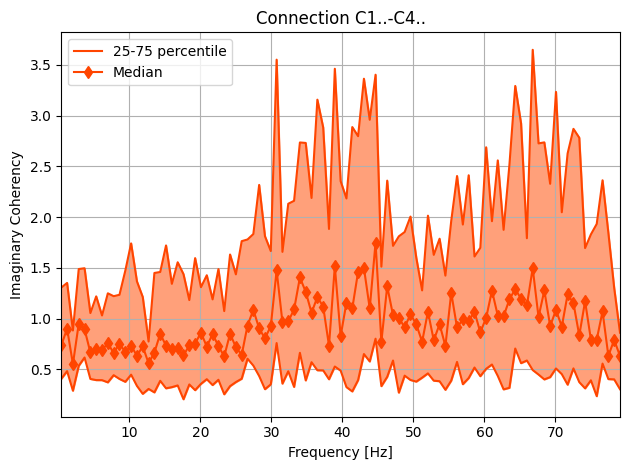

In [22]:
plot_series(fft_frequencies[:int(sample_size / 2)],
            coherence_values[:int(sample_size / 2)],
            'Frequency [Hz]',
            'Coherence',
            title='Connection ' + channel_0_name + '-' + channel_1_name,
            plot_num=50)

plot_series(fft_frequencies[:int(sample_size / 2)],
            imaginary_coherency_values[:int(sample_size / 2)],
            'Frequency [Hz]',
            'Imaginary Coherency',
            title='Connection ' + channel_0_name + '-' + channel_1_name,
            plot_num=50)

plt.show()

We estimate how the signal connectivity varies in function of different frequency bands.

In [23]:
delta_band_indexes = [np.argmin(np.abs(fft_frequencies-0.5)), np.argmin(np.abs(fft_frequencies-4))]
theta_band_indexes = [np.argmin(np.abs(fft_frequencies-4)), np.argmin(np.abs(fft_frequencies-8))]
alpha_band_indexes = [np.argmin(np.abs(fft_frequencies-8)), np.argmin(np.abs(fft_frequencies-14))]
beta_band_indexes = [np.argmin(np.abs(fft_frequencies-14)), np.argmin(np.abs(fft_frequencies-30))]

In [24]:
delta_coherence = np.mean(coherence_values[delta_band_indexes[0]:delta_band_indexes[1]])
delta_imaginary_coherency = np.mean(imaginary_coherency_values[delta_band_indexes[0]:delta_band_indexes[1]])
print('Delta coherence: ', delta_coherence)
print('Delta imaginary coherency: ', delta_imaginary_coherency)
theta_coherence = np.mean(coherence_values[theta_band_indexes[0]:theta_band_indexes[1]])
theta_imaginary_coherency = np.mean(imaginary_coherency_values[theta_band_indexes[0]:theta_band_indexes[1]])
print('Theta coherence: ', theta_coherence)
print('Theta imaginary coherency: ', theta_imaginary_coherency)
alpha_coherence = np.mean(coherence_values[alpha_band_indexes[0]:alpha_band_indexes[1]])
alpha_imaginary_coherency = np.mean(imaginary_coherency_values[alpha_band_indexes[0]:alpha_band_indexes[1]])
print('Alpha coherence: ', alpha_coherence)
print('Alpha imaginary coherency: ', alpha_imaginary_coherency)
beta_coherence = np.mean(coherence_values[beta_band_indexes[0]:beta_band_indexes[1]])
beta_imaginary_coherency = np.mean(imaginary_coherency_values[beta_band_indexes[0]:beta_band_indexes[1]])
print('Beta coherence: ', beta_coherence)
print('Beta imaginary coherency: ', beta_imaginary_coherency)

## we have higher values for lower frequencies
##

Delta coherence:  2.9710336855952173
Delta imaginary coherency:  2.3945112825582537
Theta coherence:  1.8864125506799085
Theta imaginary coherency:  1.231687953148648
Alpha coherence:  1.9795133712715192
Alpha imaginary coherency:  1.2977849348201667
Beta coherence:  2.4325540919345174
Beta imaginary coherency:  1.7901434007179742


Coherency allows us to evaluate how the two signals are interconnected in the frequency domain. If we want to estimate the channels' connectivity in the time domain, we need to consider other approaches, e.g., based on the instantaneous phase.

**YOUR TURN**

You are asked to compute the following connectivity metrics:

*   the Phase Locking Value (PLV);
*   the Phase Lag Index (PLI).

they are in time domain which are very beneficial. like to know in the first 10 seconds sth has a value and then for 20 seconds has another val.

Notably, the above metrics are based on the instantaneous phase of the target channels, which can be obtained from the channels' analytic representations. To this goal, you may use the function `scipy.signal.hilbert` of the `scipy` library.

In [25]:
channel_0_analytical_values = scipy.signal.hilbert(channel_0_values)  # Analytic representation of channel 0
channel_1_analytical_values = scipy.signal.hilbert(channel_1_values)  # Analytic representation of channel 1

In [26]:
channel_0_instantanoeus_phases = np.angle(channel_0_analytical_values)  # Instantanoeus phase of channel 0
channel_1_instantanoeus_phases = np.angle(channel_1_analytical_values)  # Instantanoeus phase of channel 1

In particular, to capture how signal connections vary in time, you are asked to segment channels 0 and 1 into overlapped windows and estimate the PLV and PLI values for each of the window.

To do so, you can extend the method `get_phase_connection()`.

In [27]:
## window shift lower than window duration and duration depends on sampling frequency. for EEG 2 second is considered good!

def get_phase_connection(phases_0: np.ndarray,
                         phases_1: np.ndarray,
                         window_duration: float,
                         window_shift: float,
                         sampling_period: float):

  sample_limit = len(phases_0) # The index of the last sample of the series

  window_times = []
  plv_per_window = []
  pli_per_window = []

  sample_window_duration = int(window_duration / sampling_period)  # Window duration in sample
  sample_window_shift = int(window_shift / sampling_period)  # Window shift in sample

  window_start_sample = 0  # Starting sample of the window
  window_end_sample = sample_window_duration  # Ending sample of the window

  while window_end_sample < sample_limit:

    # We select the portion of the series associated with the window range

    window_phases_0 = phases_0[window_start_sample:window_end_sample]
    window_phases_1 = phases_1[window_start_sample:window_end_sample]

    plv = np.abs(np.mean(np.exp(1j * (window_phases_0 - window_phases_1)))) # Compute the Phase Locking Value (PLV)

    pli = np.abs(np.mean(np.sign(np.sin(window_phases_0 - window_phases_1)))) # Compute the Phase Lag Index (PLI)

    window_times.append(window_start_sample * sampling_period)  # Append the new time reference

    plv_per_window.append(plv) # Append the new PLV value
    pli_per_window.append(pli) # Append the new PLI value

    # We update the starting and ending samples of the window

    window_start_sample += sample_window_shift
    window_end_sample = window_start_sample + sample_window_duration

  return window_times, plv_per_window, pli_per_window

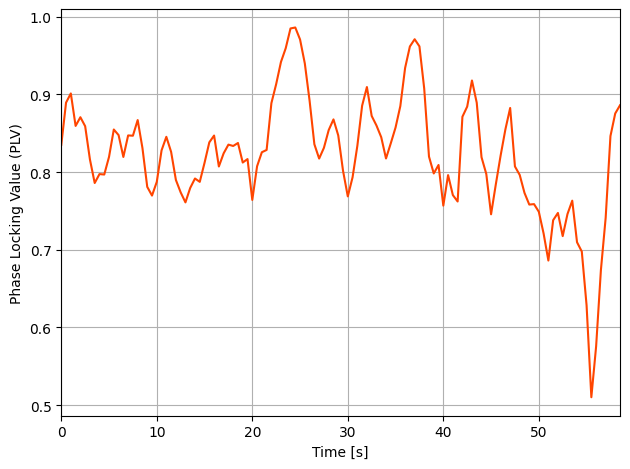

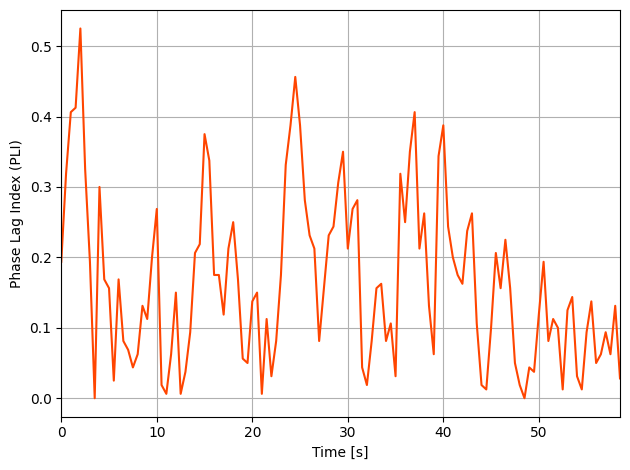

In [28]:
window_duration = 2 # Choose the window duration in second
window_shift = 0.5 # Choose the window shift in second

window_times, plv_per_window, pli_per_window =\
  get_phase_connection(channel_0_instantanoeus_phases,
                       channel_1_instantanoeus_phases,
                       window_duration,
                       window_shift,
                       sampling_period)

plot_series(window_times,
            plv_per_window,
            'Time [s]',
            'Phase Locking Value (PLV)')

plot_series(window_times,
            pli_per_window,
            'Time [s]',
            'Phase Lag Index (PLI)')

plt.show()

**HOW TO COMPLETE THE LAB**

To complete the laboratory, you must compute the PLV and the PLI for each couple of channels and for each EEG record associated with a target patient. You can consider patient S001 or any other patient in the dataset.

By doing so, you will obtain multiple connectivity values for each EEG. For instance, if an EEG is associated with 20 channels and is segmented into 100 windows, you will obtaina a total of 20x19x100=38'000 connectivity values.

The results of the laboratory, including the figures reporting the connectivity distribution of each EEG signal, must included in a report.

In the report, you must compare all the EEG records of the chosen patient in terms of connectivity, considering the mean connectivity and other significant statistical measures (e.g., the standard deviation and interquartile range).

On a visual level, you can compare different connectivity distributions (each associated with a different signal) via a boxplot representation. The method `plot_boxplot()` allows you to plot the boxplot associated with multiple groups of data.

In [29]:
from scipy.signal import hilbert
# Assuming `eeg_signal` is a list where each entry is the time-series data of one channel
phases = [np.angle(hilbert(channel)) for channel in signal_values]  # Instantaneous phases for all 64 channels

In [30]:
print(len(phases))  # Should output 64

64


In [31]:
# Initialize storage for PLV and PLI values
plv_values = []  # To store PLV values for all channel pairs
pli_values = []  # To store PLI values for all channel pairs
channel_pairs = []  # To store channel pair labels (e.g., C1-C2, C1-C3,...)

num_channels = len(phases)  # Should be 64 channels

# Iterate through all unique channel pairs
for ch1 in range(num_channels):
    for ch2 in range(ch1 + 1, num_channels):  # Ensure unique pairs (ch2 > ch1)

        # Compute PLV and PLI for this channel pair
        _, plv_per_window, pli_per_window = get_phase_connection(
            phases[ch1], phases[ch2], window_duration, window_shift, sampling_period
        )

        # Store results for this channel pair
        plv_values.extend(plv_per_window)  # Append PLV values
        pli_values.extend(pli_per_window)  # Append PLI values
        channel_pairs.append(f'C{ch1 + 1}-C{ch2 + 1}')  # Label for the channel pair

# Verify number of computed PLV/PLI values
print(f"Number of channel pairs: {len(channel_pairs)}")
print(f"Number of PLV values: {len(plv_values)}")
print(f"Number of PLI values: {len(pli_values)}")

Number of channel pairs: 2016
Number of PLV values: 237888
Number of PLI values: 237888


In [32]:
# Organizing PLV and PLI values for this signal (signal 1)
plv_values_signal = plv_values  # Already computed PLV values
pli_values_signal = pli_values  # Already computed PLI values

# Store them in a list (if analyzing multiple signals later)
plv_values_per_signal = [plv_values_signal]  # List containing PLV values for each signal
pli_values_per_signal = [pli_values_signal]  # List containing PLI values for each signal

# Add a label for the signal for easy identification
labels_per_signal = ["Signal 1"]  # Update this as "Signal 2", "Signal 3", etc., for additional signals

# Verify
print(f"PLV values for Signal 1: {len(plv_values_signal)} values")
print(f"PLI values for Signal 1: {len(pli_values_signal)} values")


PLV values for Signal 1: 237888 values
PLI values for Signal 1: 237888 values


In [33]:
# Compute statistics for PLV values
mean_plv = np.mean(plv_values_signal)  # Mean
std_plv = np.std(plv_values_signal)    # Standard Deviation
iqr_plv = np.percentile(plv_values_signal, [25, 75])  # Interquartile Range (25th and 75th percentiles)

# Compute statistics for PLI values
mean_pli = np.mean(pli_values_signal)  # Mean
std_pli = np.std(pli_values_signal)    # Standard Deviation
iqr_pli = np.percentile(pli_values_signal, [25, 75])  # Interquartile Range (25th and 75th percentiles)

# Print statistics
print(f"PLV Statistics:\nMean: {mean_plv}\nStandard Deviation: {std_plv}\nInterquartile Range: {iqr_plv}")
print(f"PLI Statistics:\nMean: {mean_pli}\nStandard Deviation: {std_pli}\nInterquartile Range: {iqr_pli}")

PLV Statistics:
Mean: 0.5889818356978909
Standard Deviation: 0.2135661937440117
Interquartile Range: [0.43502091 0.75788909]
PLI Statistics:
Mean: 0.21172213919995966
Standard Deviation: 0.1598343050795442
Interquartile Range: [0.0875  0.30625]


In [34]:
eeg_files = [
    'S001R04.edf',
    'S001R06.edf',
    'S001R01.edf',
    'S001R03.edf',
    'S001R05.edf',
    'S001R02.edf'
]

In [35]:
# Initialize list to store EEG signals
eeg_signals = []

# Loop through each file, load the data, and extract signals
for file_name in eeg_files:
    print(f"Loading file: {file_name}...")
    raw_data = mne.io.read_raw_edf(path_to_patient_folder + file_name, preload=True)  # Load EEG data
    signal_values = raw_data.get_data() * 1000  # Convert to millivolts
    eeg_signals.append(signal_values)  # Append data to the list

print(f"Loaded {len(eeg_signals)} EEG signals!")

Loading file: S001R04.edf...
Extracting EDF parameters from /content/ehealth_lab_3/S001/S001R04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Loading file: S001R06.edf...
Extracting EDF parameters from /content/ehealth_lab_3/S001/S001R06.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Loading file: S001R01.edf...
Extracting EDF parameters from /content/ehealth_lab_3/S001/S001R01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Loading file: S001R03.edf...
Extracting EDF parameters from /content/ehealth_lab_3/S001/S001R03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Loading file: S001R05.edf...
Extr

In [36]:
print(f"Number of signals: {len(eeg_signals)}")
for i, signal in enumerate(eeg_signals):
    print(f"Signal {i+1}: {signal.shape} (Channels x Samples)")

Number of signals: 6
Signal 1: (64, 20000) (Channels x Samples)
Signal 2: (64, 20000) (Channels x Samples)
Signal 3: (64, 9760) (Channels x Samples)
Signal 4: (64, 20000) (Channels x Samples)
Signal 5: (64, 20000) (Channels x Samples)
Signal 6: (64, 9760) (Channels x Samples)


In [37]:
from scipy.signal import hilbert
# Initialize a list to store phases for all signals
phases_per_signal = []

# Loop through each EEG signal
for signal_index, eeg_signal in enumerate(eeg_signals):
    print(f"Processing Signal {signal_index + 1}...")

    # Compute instantaneous phases for each channel
    phases = [np.angle(hilbert(channel)) for channel in eeg_signal]
    phases_per_signal.append(phases)  # Store phases for this signal

print("Instantaneous phases computed for all signals!")

Processing Signal 1...
Processing Signal 2...
Processing Signal 3...
Processing Signal 4...
Processing Signal 5...
Processing Signal 6...
Instantaneous phases computed for all signals!


In [38]:
print(f"Number of signals processed: {len(phases_per_signal)}")
for i, phases in enumerate(phases_per_signal):
    print(f"Signal {i+1}: {len(phases)} channels with {len(phases[0])} samples each")

Number of signals processed: 6
Signal 1: 64 channels with 20000 samples each
Signal 2: 64 channels with 20000 samples each
Signal 3: 64 channels with 9760 samples each
Signal 4: 64 channels with 20000 samples each
Signal 5: 64 channels with 20000 samples each
Signal 6: 64 channels with 9760 samples each


In [39]:
sampling_freqs = []  # List to store sampling frequencies

for file_name in eeg_files:
    raw_data = mne.io.read_raw_edf(path_to_patient_folder + file_name, preload=True)
    sfreq = raw_data.info['sfreq']  # Extract sampling frequency
    sampling_freqs.append(sfreq)
    print(f"File: {file_name}, Sampling Frequency: {sfreq} Hz")

Extracting EDF parameters from /content/ehealth_lab_3/S001/S001R04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
File: S001R04.edf, Sampling Frequency: 160.0 Hz
Extracting EDF parameters from /content/ehealth_lab_3/S001/S001R06.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
File: S001R06.edf, Sampling Frequency: 160.0 Hz
Extracting EDF parameters from /content/ehealth_lab_3/S001/S001R01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
File: S001R01.edf, Sampling Frequency: 160.0 Hz
Extracting EDF parameters from /content/ehealth_lab_3/S001/S001R03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
File:

In [40]:
# Set parameters for all signals
window_duration = 2  # Window duration in seconds
window_shift = 0.5   # Window shift in seconds

# Convert duration and shift to samples
window_samples = int(window_duration * 160)  # 2 seconds × 160 Hz
shift_samples = int(window_shift * 160)      # 0.5 seconds × 160 Hz

# Print calculated values
print(f"Window size (samples): {window_samples}")
print(f"Window shift (samples): {shift_samples}")

Window size (samples): 320
Window shift (samples): 80


In [41]:
# Initialize lists to store PLV and PLI values for all signals
plv_values_all_signals = []
pli_values_all_signals = []

# Process each signal
for signal_index, signal_phases in enumerate(phases_per_signal):
    print(f"Processing Signal {signal_index + 1}...")

    # Initialize lists for this signal's PLV and PLI values
    plv_values = []
    pli_values = []

    num_channels = len(signal_phases)  # Number of channels (64)

    # Loop through all unique channel pairs
    for ch1 in range(num_channels):
        for ch2 in range(ch1 + 1, num_channels):  # Avoid duplicate pairs
            # Initialize list for PLV/PLI across all windows
            pair_plv = []
            pair_pli = []

            # Segment the data into overlapping windows
            for start in range(0, len(signal_phases[ch1]) - window_samples + 1, shift_samples):
                end = start + window_samples
                phase_diff = signal_phases[ch1][start:end] - signal_phases[ch2][start:end]  # Phase difference

                # Compute PLV and PLI for this window
                plv = abs(np.mean(np.exp(1j * phase_diff)))  # PLV formula
                pli = abs(np.mean(np.sign(np.sin(phase_diff))))  # PLI formula

                # Append to window values
                pair_plv.append(plv)
                pair_pli.append(pli)

            # Store the pair's PLV/PLI across all windows
            plv_values.extend(pair_plv)
            pli_values.extend(pair_pli)

    # Append the signal's PLV/PLI values to the main lists
    plv_values_all_signals.append(plv_values)
    pli_values_all_signals.append(pli_values)

print("PLV and PLI computation complete for all six signals!")

Processing Signal 1...
Processing Signal 2...
Processing Signal 3...
Processing Signal 4...
Processing Signal 5...
Processing Signal 6...
PLV and PLI computation complete for all six signals!


<ipython-input-42-1e893e2e1d81>:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plv_values_all_signals, labels=signal_labels)


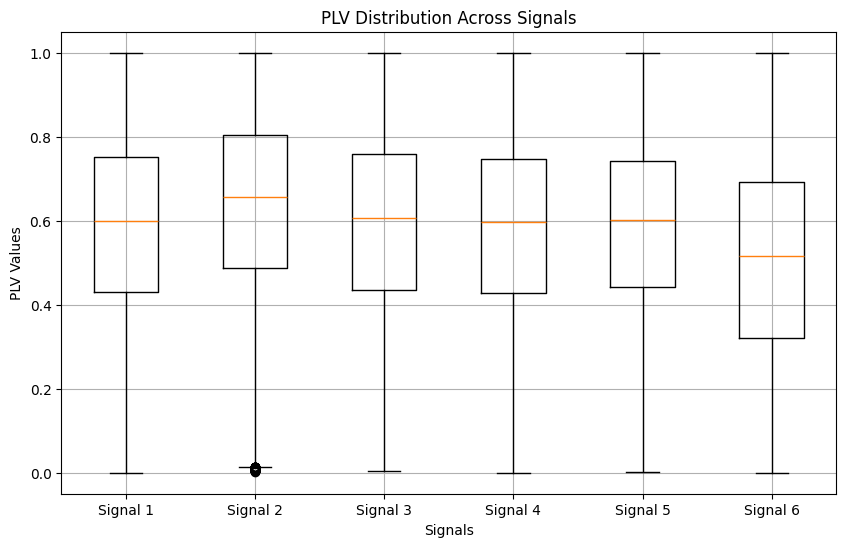

<ipython-input-42-1e893e2e1d81>:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(pli_values_all_signals, labels=signal_labels)


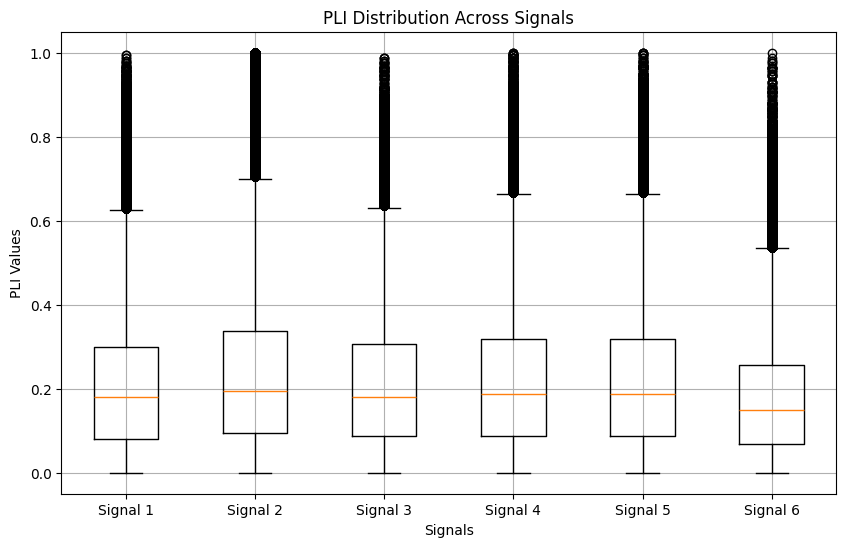

In [42]:
import matplotlib.pyplot as plt

# Example labels for signals
signal_labels = [f"Signal {i+1}" for i in range(len(plv_values_all_signals))]

# PLV boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(plv_values_all_signals, labels=signal_labels)
plt.title("PLV Distribution Across Signals")
plt.xlabel("Signals")
plt.ylabel("PLV Values")
plt.grid(True)
plt.show()

# PLI boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(pli_values_all_signals, labels=signal_labels)
plt.title("PLI Distribution Across Signals")
plt.xlabel("Signals")
plt.ylabel("PLI Values")
plt.grid(True)
plt.show()


In [43]:
import numpy as np

# Initialize lists for storing statistical results
mean_plv_per_signal = []
std_plv_per_signal = []
iqr_plv_per_signal = []

mean_pli_per_signal = []
std_pli_per_signal = []
iqr_pli_per_signal = []

# Loop through PLV and PLI values for all signals
for signal_index in range(len(plv_values_all_signals)):
    # Extract PLV and PLI values for this signal
    plv_values = np.array(plv_values_all_signals[signal_index])
    pli_values = np.array(pli_values_all_signals[signal_index])

    # Compute statistical measures for PLV
    mean_plv = np.mean(plv_values)
    std_plv = np.std(plv_values)
    iqr_plv = np.percentile(plv_values, 75) - np.percentile(plv_values, 25)

    # Compute statistical measures for PLI
    mean_pli = np.mean(pli_values)
    std_pli = np.std(pli_values)
    iqr_pli = np.percentile(pli_values, 75) - np.percentile(pli_values, 25)

    # Append results to lists
    mean_plv_per_signal.append(mean_plv)
    std_plv_per_signal.append(std_plv)
    iqr_plv_per_signal.append(iqr_plv)

    mean_pli_per_signal.append(mean_pli)
    std_pli_per_signal.append(std_pli)
    iqr_pli_per_signal.append(iqr_pli)

# Print summary results
for i in range(len(mean_plv_per_signal)):
    print(f"Signal {i+1}: Mean PLV = {mean_plv_per_signal[i]:.3f}, SD PLV = {std_plv_per_signal[i]:.3f}, IQR PLV = {iqr_plv_per_signal[i]:.3f}")
    print(f"Signal {i+1}: Mean PLI = {mean_pli_per_signal[i]:.3f}, SD PLI = {std_pli_per_signal[i]:.3f}, IQR PLI = {iqr_pli_per_signal[i]:.3f}")


Signal 1: Mean PLV = 0.583, SD PLV = 0.213, IQR PLV = 0.320
Signal 1: Mean PLI = 0.208, SD PLI = 0.155, IQR PLI = 0.219
Signal 2: Mean PLV = 0.635, SD PLV = 0.213, IQR PLV = 0.315
Signal 2: Mean PLI = 0.238, SD PLI = 0.190, IQR PLI = 0.244
Signal 3: Mean PLV = 0.590, SD PLV = 0.214, IQR PLV = 0.324
Signal 3: Mean PLI = 0.211, SD PLI = 0.160, IQR PLI = 0.219
Signal 4: Mean PLV = 0.580, SD PLV = 0.213, IQR PLV = 0.320
Signal 4: Mean PLI = 0.218, SD PLI = 0.161, IQR PLI = 0.231
Signal 5: Mean PLV = 0.585, SD PLV = 0.204, IQR PLV = 0.301
Signal 5: Mean PLI = 0.219, SD PLI = 0.165, IQR PLI = 0.231
Signal 6: Mean PLV = 0.507, SD PLV = 0.233, IQR PLV = 0.371
Signal 6: Mean PLI = 0.180, SD PLI = 0.138, IQR PLI = 0.187


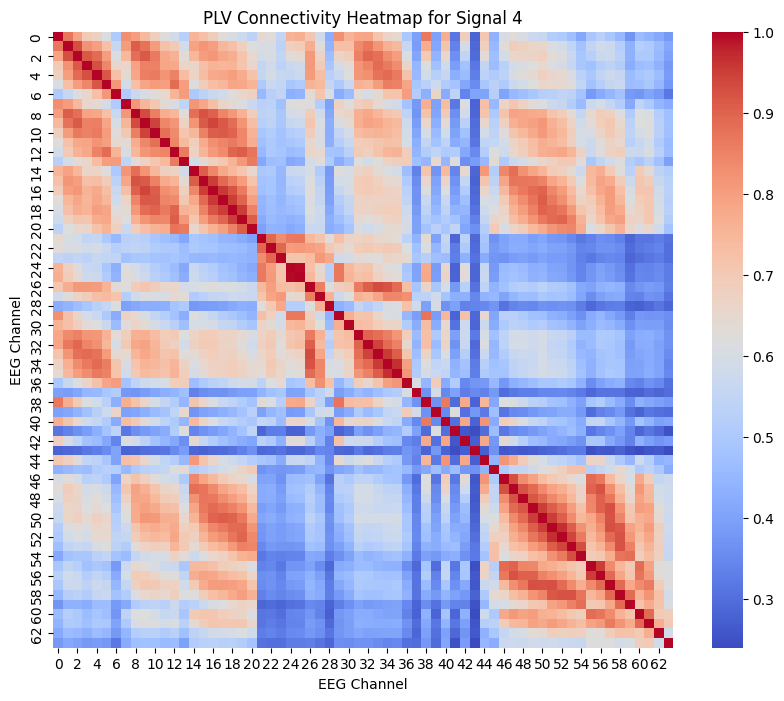

In [65]:
import numpy as np
import seaborn as sns

# Get the number of unique channel pairs
num_pairs = 64 * (64 - 1) // 2  # Calculate the number of unique channel pairs (2016)

# Reshape the PLV values for the first signal
plv_matrix = np.array(plv_values_all_signals[0]).reshape(num_pairs, -1)  # num_pairs rows, -1 automatically infers the number of columns

# Calculate the average PLV across all windows for each channel pair
avg_plv_matrix = np.mean(plv_matrix, axis=1)

# Reshape the average PLV to a 64x64 matrix (symmetric with diagonal=1)
connectivity_matrix = np.zeros((64, 64))
pair_index = 0
for i in range(64):
    for j in range(i + 1, 64):
        connectivity_matrix[i, j] = connectivity_matrix[j, i] = avg_plv_matrix[pair_index]
        pair_index += 1

# Set the diagonal values to 1 (since self-connectivity is perfect)
np.fill_diagonal(connectivity_matrix, 1)

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(connectivity_matrix, cmap="coolwarm", annot=False)
plt.title("PLV Connectivity Heatmap for Signal 4")
plt.xlabel("EEG Channel")
plt.ylabel("EEG Channel")
plt.show()

In [46]:
# Compute the average connectivity for each EEG channel
mean_plv_per_channel = np.mean(plv_matrix, axis=1)

# Sort channels by connectivity strength
sorted_channels = np.argsort(mean_plv_per_channel)[::-1]  # Highest connectivity first

# Print the top most connected channels
print("Most connected channels based on PLV:")
for i in range(10):  # Show top 10 channels
    print(f"Channel {sorted_channels[i]} - Avg PLV: {mean_plv_per_channel[sorted_channels[i]]:.3f}")


Most connected channels based on PLV:
Channel 1236 - Avg PLV: 0.994
Channel 1938 - Avg PLV: 0.968
Channel 1581 - Avg PLV: 0.967
Channel 888 - Avg PLV: 0.957
Channel 1551 - Avg PLV: 0.955
Channel 1911 - Avg PLV: 0.952
Channel 981 - Avg PLV: 0.952
Channel 1980 - Avg PLV: 0.951
Channel 935 - Avg PLV: 0.950
Channel 840 - Avg PLV: 0.950


In [48]:
import pandas as pd

# Flatten the PLV matrix and get top connections
num_channels = plv_matrix.shape[0]  # Number of rows in plv_matrix
num_windows = plv_matrix.shape[1]   # Number of columns in plv_matrix

plv_pairs = [(i, j, plv_matrix[i, j])
             for i in range(num_channels)
             for j in range(num_windows)] # Iterate through the correct dimensions

# Convert to DataFrame for sorting
df = pd.DataFrame(plv_pairs, columns=["Channel 1", "Channel 2", "PLV"])
df_sorted = df.sort_values(by="PLV", ascending=False)

# Display top 10 strongest connections
print("Top 10 most connected EEG channel pairs:")
print(df_sorted.head(10))

Top 10 most connected EEG channel pairs:
        Channel 1  Channel 2       PLV
305519       1236        227  0.999855
305357       1236         65  0.999851
305324       1236         32  0.999822
305483       1236        191  0.999814
305412       1236        120  0.999680
305482       1236        190  0.999678
305325       1236         33  0.999673
305356       1236         64  0.999665
305303       1236         11  0.999542
305393       1236        101  0.999524


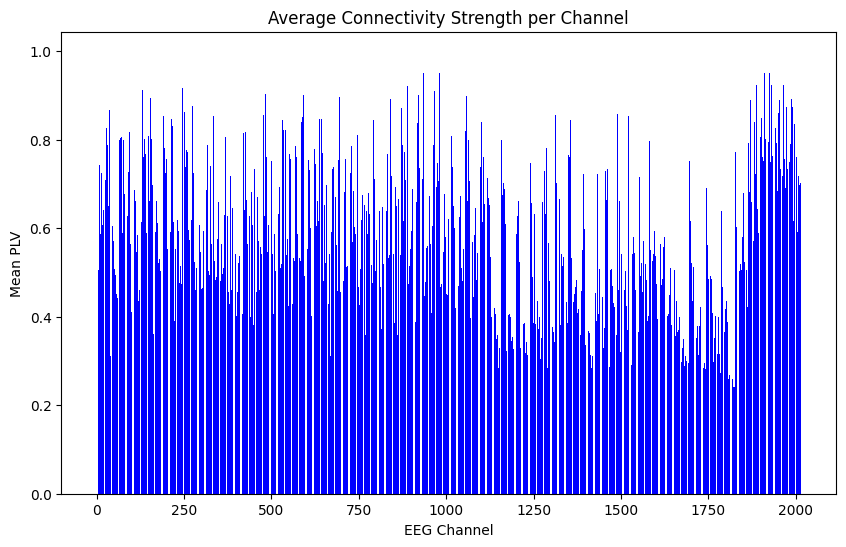

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(range(len(mean_plv_per_channel)), mean_plv_per_channel, color='blue')
plt.xlabel("EEG Channel")
plt.ylabel("Mean PLV")
plt.title("Average Connectivity Strength per Channel")
plt.show()


Most connected EEG channels based on PLV:
Iz.. - Avg PLV: 0.929
Fc5. - Avg PLV: 0.870
F8.. - Avg PLV: 0.867
Fc6. - Avg PLV: 0.829
Af8. - Avg PLV: 0.826
C5.. - Avg PLV: 0.804
Fc3. - Avg PLV: 0.793
F3.. - Avg PLV: 0.788
F5.. - Avg PLV: 0.784
Ft8. - Avg PLV: 0.769


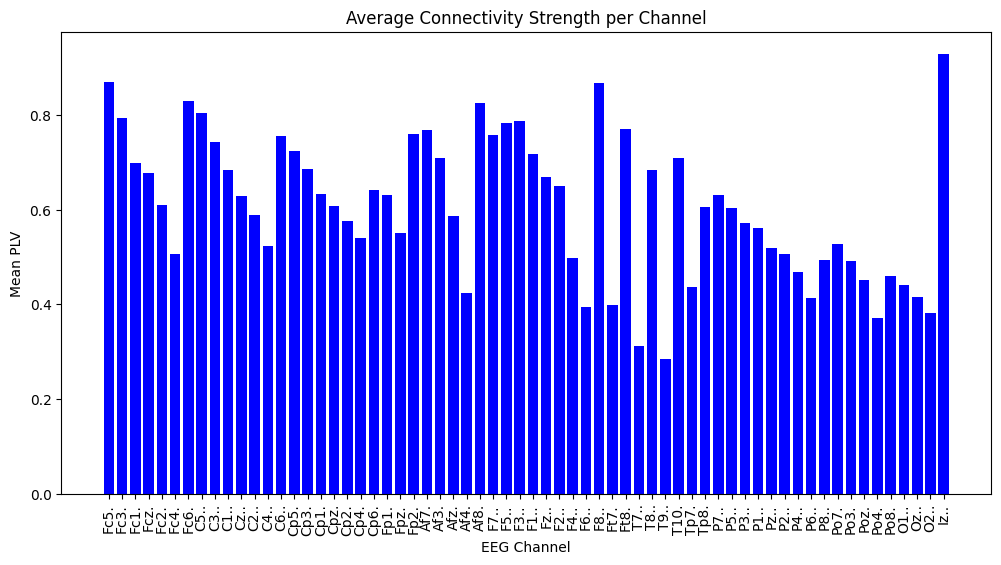

In [51]:
# existing PLV values per channel (already plotted)
num_channels = len(channel_names)
mean_plv_per_channel = np.array(mean_plv_per_channel)  # Ensure it's a NumPy array

# Sort channels based on highest connectivity
sorted_indices = np.argsort(mean_plv_per_channel)[::-1]  # Highest PLV first

# Get the indices of the top channels within the valid range
top_channel_indices = [i for i in sorted_indices if i < num_channels]

sorted_channels = [channel_names[i] for i in top_channel_indices]  # Mapping indices to names

# Print the top most connected channels
print("Most connected EEG channels based on PLV:")
for i in range(min(10, len(top_channel_indices))):  # Show up to top 10
    channel_index = top_channel_indices[i]
    print(f"{sorted_channels[i]} - Avg PLV: {mean_plv_per_channel[channel_index]:.3f}")

# Plot with correct labels
plt.figure(figsize=(12, 6))
plt.bar(channel_names, mean_plv_per_channel[:num_channels], color='blue')  # Use mean PLV for individual channels
plt.xticks(rotation=90)  # Rotate labels for readability
plt.xlabel("EEG Channel")
plt.ylabel("Mean PLV")
plt.title("Average Connectivity Strength per Channel")
plt.show()

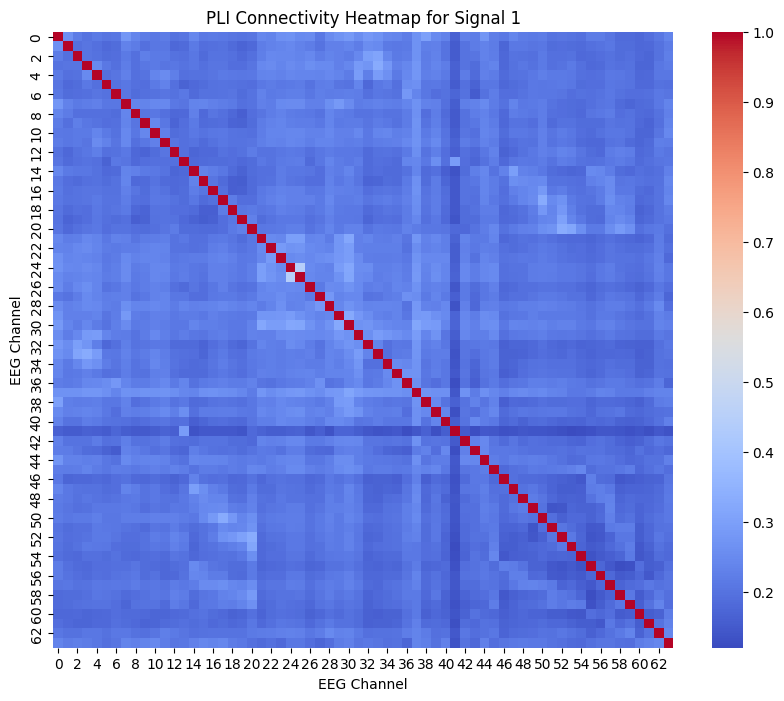

In [54]:
# Assuming PLI matrix is stored similar to PLV
pli_matrix = np.array(pli_values_all_signals[0])  # Adjust index for the desired signal

# Get the number of unique channel pairs
num_pairs = 64 * (64 - 1) // 2  # Calculate the number of unique channel pairs (2016)

# Reshape the PLI values for the first signal to a 2D matrix
pli_matrix = pli_matrix.reshape(num_pairs, -1)  # -1 automatically infers the number of columns (windows)

# Calculate the average PLI across all windows for each channel pair
avg_pli_matrix = np.mean(pli_matrix, axis=1)

# Reshape the average PLI to a 64x64 matrix (symmetric with diagonal=1)
pli_connectivity_matrix = np.zeros((64, 64))
pair_index = 0
for i in range(64):
    for j in range(i + 1, 64):
        pli_connectivity_matrix[i, j] = pli_connectivity_matrix[j, i] = avg_pli_matrix[pair_index]
        pair_index += 1

# Set the diagonal values to 1 (since self-connectivity is perfect)
np.fill_diagonal(pli_connectivity_matrix, 1)

plt.figure(figsize=(10, 8))
sns.heatmap(pli_connectivity_matrix, cmap="coolwarm", annot=False)
plt.title("PLI Connectivity Heatmap for Signal 1")
plt.xlabel("EEG Channel")
plt.ylabel("EEG Channel")
plt.show()

In [59]:
# Compute the average PLI for each EEG channel
mean_pli_per_channel = np.mean(pli_matrix, axis=1)

# Sort channels by directional connectivity strength
sorted_indices = np.argsort(mean_pli_per_channel)[::-1]  # Highest PLI first

# Filter sorted indices to be within the valid range of channel_names
sorted_indices = [i for i in sorted_indices if i < len(channel_names)]

sorted_channels = [channel_names[i] for i in sorted_indices]  # Mapping indices to names

# Print the top most directionally connected channels
print("Most directionally connected EEG channels based on PLI:")
for i in range(min(10, len(sorted_indices))):  # Show top 10 channels, up to the available number
    print(f"{sorted_channels[i]} - Avg PLI: {mean_pli_per_channel[sorted_indices[i]]:.3f}")

Most directionally connected EEG channels based on PLI:
F8.. - Avg PLI: 0.300
F7.. - Avg PLI: 0.284
F3.. - Avg PLI: 0.281
Fc6. - Avg PLI: 0.277
T10. - Avg PLI: 0.274
Af8. - Avg PLI: 0.269
F6.. - Avg PLI: 0.267
Fp2. - Avg PLI: 0.267
F1.. - Avg PLI: 0.265
Fc5. - Avg PLI: 0.263


Most directionally connected EEG channels based on PLI:
F8.. - Avg PLI: 0.264
F5.. - Avg PLI: 0.253
Af7. - Avg PLI: 0.245
F7.. - Avg PLI: 0.244
Af3. - Avg PLI: 0.244
Af8. - Avg PLI: 0.242
F3.. - Avg PLI: 0.242
Fc5. - Avg PLI: 0.239
Fp2. - Avg PLI: 0.238
C5.. - Avg PLI: 0.233


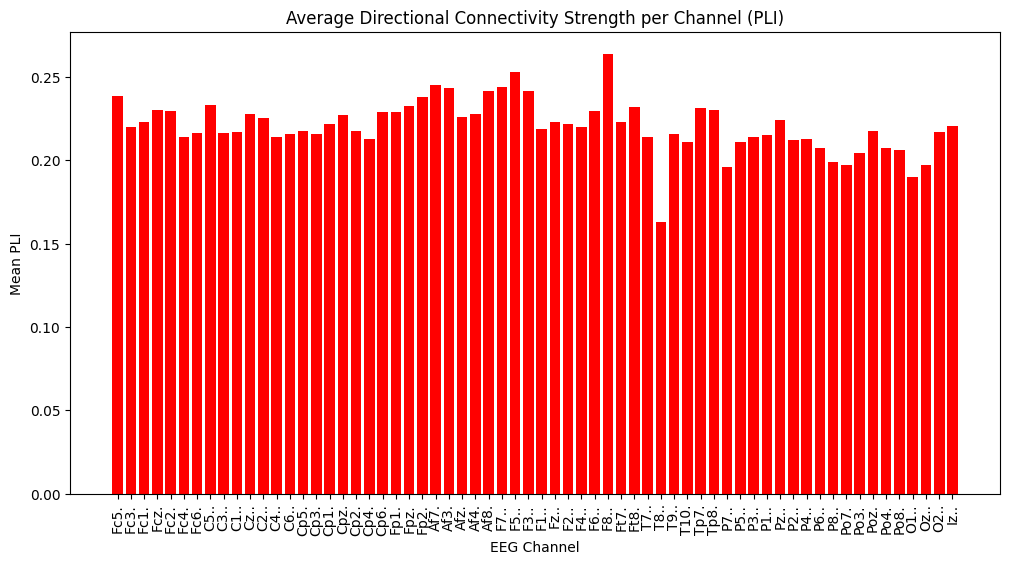

In [62]:
# Compute the average PLI for each EEG channel
mean_pli_per_channel = np.mean(pli_connectivity_matrix, axis=1)  # Calculate mean across columns for each channel

# Sort channels by directional connectivity strength
sorted_indices = np.argsort(mean_pli_per_channel)[::-1]  # Highest PLI first

# Filter sorted indices to be within the valid range of channel_names
sorted_indices = [i for i in sorted_indices if i < len(channel_names)]

sorted_channels = [channel_names[i] for i in sorted_indices]  # Mapping indices to names

# Print the top most directionally connected channels
print("Most directionally connected EEG channels based on PLI:")
for i in range(min(10, len(sorted_indices))):  # Show top 10 channels, up to the available number
    print(f"{sorted_channels[i]} - Avg PLI: {mean_pli_per_channel[sorted_indices[i]]:.3f}")

# Plotting (modified)
plt.figure(figsize=(12, 6))
plt.bar(channel_names, mean_pli_per_channel, color='red')  # Use the updated mean_pli_per_channel
plt.xticks(rotation=90)  # Rotate labels for readability
plt.xlabel("EEG Channel")
plt.ylabel("Mean PLI")
plt.title("Average Directional Connectivity Strength per Channel (PLI)")
plt.show()

In [63]:
print(f"pli_matrix shape: {np.array(pli_matrix).shape}")
print(f"pli_connectivity_matrix shape: {np.array(pli_connectivity_matrix).shape}")

pli_matrix shape: (2016, 247)
pli_connectivity_matrix shape: (64, 64)


Most directionally connected EEG channels based on PLI:
F8.. - Avg PLI: 0.264
F5.. - Avg PLI: 0.253
Af7. - Avg PLI: 0.245
F7.. - Avg PLI: 0.244
Af3. - Avg PLI: 0.244
Af8. - Avg PLI: 0.242
F3.. - Avg PLI: 0.242
Fc5. - Avg PLI: 0.239
Fp2. - Avg PLI: 0.238
C5.. - Avg PLI: 0.233


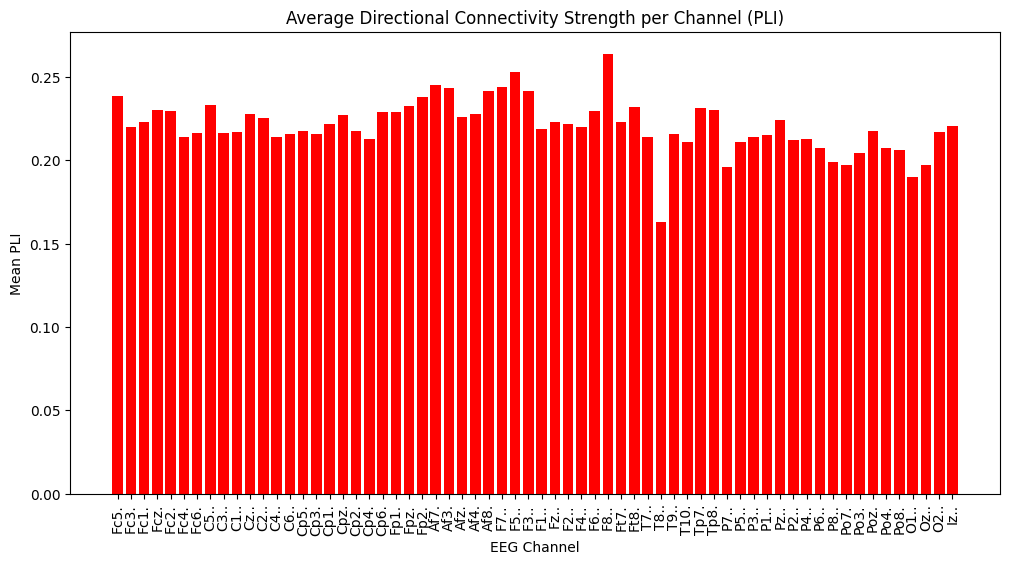

In [64]:
# Use the correct PLI matrix for averaging
mean_pli_per_channel = np.mean(pli_connectivity_matrix, axis=1)  # Compute directional influence

# Sort channels by connectivity strength
sorted_indices = np.argsort(mean_pli_per_channel)[::-1]  # Highest PLI first
sorted_channels = [channel_names[i] for i in sorted_indices]  # Map indices to names

# Print top directionally connected channels
print("Most directionally connected EEG channels based on PLI:")
for i in range(min(10, len(sorted_indices))):
    print(f"{sorted_channels[i]} - Avg PLI: {mean_pli_per_channel[sorted_indices[i]]:.3f}")

# Plot corrected visualization
plt.figure(figsize=(12, 6))
plt.bar(channel_names, mean_pli_per_channel, color='red')
plt.xticks(rotation=90)  # Rotate labels for readability
plt.xlabel("EEG Channel")
plt.ylabel("Mean PLI")
plt.title("Average Directional Connectivity Strength per Channel (PLI)")
plt.show()


In [ ]:
plv_values_per_signal = [plv_values_signal_0, plv_values_signal_1, ...] # Insert the PLV values associated with each signal
pli_values_per_signal = [pli_values_signal_0, pli_values_signal_1, ...] # Insert the PLI values associated with each signal
label_per_signal = [label_signal_0, label_signal_1, ...]  # Insert the label for describing each signal

plot_boxplots(plv_values_per_signal,
              label_per_signal,
              ylabel='PLV',
              xlabel='Signal')

plot_boxplots(pli_values_per_signal,
              label_per_signal,
              ylabel='PLI',
              xlabel='Signal')

plt.show()